# 📚 [LAB 12] 5. 로지스틱 회귀 (이항분류)

In [2]:
# 라이브러리 기본 참조
from hossam import load_data
from pandas import DataFrame, get_dummies
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np

# 로지스틱을 위한 참조
import statsmodels.api as sm

# 로지스틱의 결과 판별을 위한 참조
# -> 머신러닝 라이브러리를 미리 사용함
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
)

In [3]:
origin = load_data("graduate")
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab12_/graduate.xlsx
[desc] 방사선학 석사과정 대학원생 모집 현황을 조사한 가상의 데이터
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (400, 4)
열 개수: 4
행 개수: 400

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   합격여부    400 non-null    int64  
 1   필기점수    400 non-null    int64  
 2   학부성적    400 non-null    float64
 3   병원경력    400 non-null    object 
dtypes: float64(1), int64(2), object(1)
memory usage: 12.6+ KB
None


,합격여부,필기점수,학부성적,병원경력
0,0,380,3.61,1~5년
1,1,660,3.67,1~5년
2,1,800,4.00,10년 이상
3,1,640,3.19,1년 미만
4,0,520,2.93,1년 미만


In [4]:
origin["병원경력"].unique()

array(['1~5년', '10년 이상', '1년 미만', '5~10년'], dtype=object)

In [6]:
df = origin.copy()
df["병원경력"] = df["병원경력"].map(
    {"1년 미만": 0, "1~5년": 1, "5~10년": 2, "10년 이상": 3}
)
df["병원경력"].unique()

array([1, 3, 0, 2])

In [7]:
df2 = get_dummies(df, columns=["병원경력"], dtype="int", drop_first=True)
df2.head()

,합격여부,필기점수,학부성적,병원경력_1,병원경력_2,병원경력_3
0,0,380,3.61,1,0,0
1,1,660,3.67,1,0,0
2,1,800,4.00,0,0,1
3,1,640,3.19,0,0,0
4,0,520,2.93,0,0,0


In [8]:
yname = "합격여부"  # 종속변수 이름
x = df2.drop(yname, axis=1)  # 독립변수만 추출(DataFrame 형태)
y = df2[yname]  # 종속변수만 추출(Series 형태)
x_input = sm.add_constant(x)  # 독립변수에 상수항 추가
display(x_input)
fit = sm.Logit(y, x_input).fit()
tbl1 = fit.summary()
print(tbl1)

,const,필기점수,학부성적,병원경력_1,병원경력_2,병원경력_3
0,1.0,380,3.61,1,0,0
1,1.0,660,3.67,1,0,0
2,1.0,800,4.00,0,0,1
3,1.0,640,3.19,0,0,0
4,1.0,520,2.93,0,0,0
...,...,...,...,...,...,...
395,1.0,620,4.00,0,1,0
396,1.0,560,3.04,1,0,0
397,1.0,460,2.63,0,1,0
398,1.0,700,3.65,0,1,0


Optimization terminated successfully.
         Current function value: 0.573147
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                   합격여부   No. Observations:                  400
Model:                          Logit   Df Residuals:                      394
Method:                           MLE   Df Model:                            5
Date:                Mon, 15 Dec 2025   Pseudo R-squ.:                 0.08292
Time:                        16:17:06   Log-Likelihood:                -229.26
converged:                       True   LL-Null:                       -249.99
Covariance Type:            nonrobust   LLR p-value:                 7.578e-08
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.5414      1.138     -4.869      0.000      -7.772      -3.311
필기점수           0.0023      0.

In [9]:
y_true = df2["합격여부"]
y_true

0      0
1      1
2      1
3      1
4      0
      ..
395    0
396    0
397    0
398    0
399    0
Name: 합격여부, Length: 400, dtype: int64

In [10]:
y_pred = fit.predict(x_input)
y_pred

0      0.172627
1      0.292175
2      0.738408
3      0.178385
4      0.118354
         ...   
395    0.488670
396    0.165504
397    0.181062
398    0.463667
399    0.300731
Length: 400, dtype: float64

In [11]:
y_pred_fix = y_pred > 0.5
y_pred_fix

0      False
1      False
2       True
3      False
4      False
       ...  
395    False
396    False
397    False
398    False
399    False
Length: 400, dtype: bool

In [12]:
cm = confusion_matrix(y_true, y_pred_fix)
tn, fp, fn, tp = cm.ravel()
tn, fp, fn, tp

(np.int64(254), np.int64(19), np.int64(97), np.int64(30))

In [13]:
cmdf = DataFrame(
    cm,
    index=["Actual 0 (TN/FP)", "Actual 1 (FN/TP)"],
    columns=["Predicted (Negative)", "Predicted (Positive)"],
)
cmdf

,Predicted (Negative),Predicted (Positive)
Actual 0 (TN/FP),254,19
Actual 1 (FN/TP),97,30


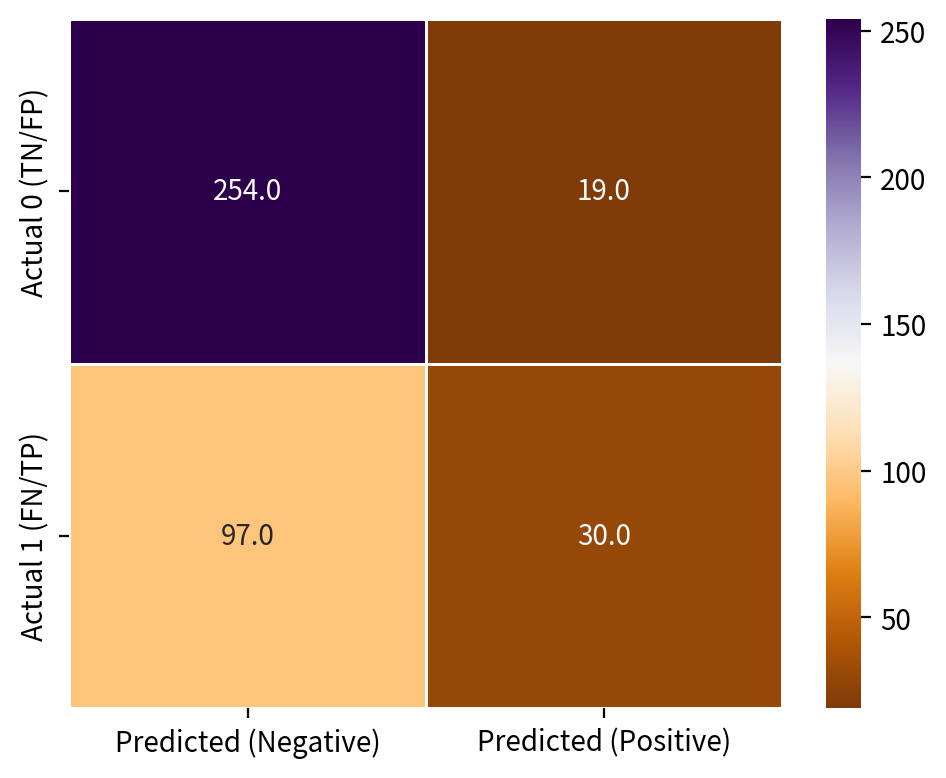

In [14]:
# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 1000
height_px = 800
rows = 1
cols = 1
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

# 2) 그래프 그리기 -> seaborn 사용
sb.heatmap(data=cmdf, annot=True, fmt="0.1f", linewidth=0.5, cmap="PuOr")

# 3) 그래프 꾸미기 (필요시 제목/축 라벨 설정)
ax.set_title("", fontsize=12, pad=8)
ax.set_xlabel("", fontsize=8, labelpad=5)
ax.set_ylabel("", fontsize=8, labelpad=5)

plt.tight_layout()
plt.show()
plt.close()

In [15]:
(tn + tp) / (tn + fp + fn + tp)

np.float64(0.71)

In [16]:
acc = accuracy_score(y_true, y_pred_fix)
acc

0.71

In [17]:
# pre = tp / (fp + tp)
pre = precision_score(y_true, y_pred_fix)
pre

0.6122448979591837

In [18]:
recall = tp / (tp + fn)
recall = recall_score(y_true, y_pred_fix)
recall

0.23622047244094488

In [19]:
fpr = fp / (fp + tn)
fpr

np.float64(0.0695970695970696)

In [20]:
tnr = 1 - fpr
tnr

np.float64(0.9304029304029304)

In [21]:
# f1 = 2 * ((pre * recall) / (pre + recall))
f1 = f1_score(y_true, y_pred_fix)
f1

0.3409090909090909

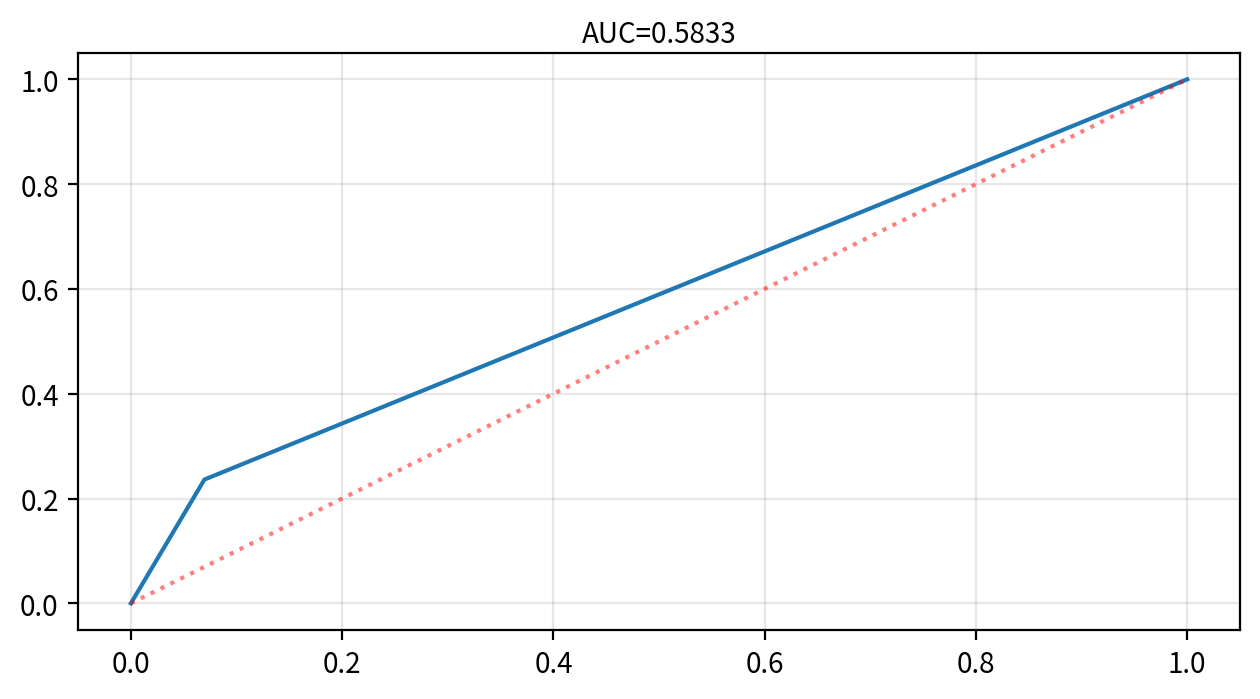

In [22]:
ras = roc_auc_score(y_true, y_pred_fix)
roc_fpr, roc_tpr, thresholds = roc_curve(y_true, y_pred_fix)
# 1) 그래프 초기화
width_px = 1280  # 그래프 가로 크기
height_px = 720  # 그래프 세로 크기
rows = 1  # 그래프 행 수
cols = 1  # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# 2) LinePlot 그리기
sb.lineplot(x=roc_fpr, y=roc_tpr)
sb.lineplot(x=[0, 1], y=[0, 1], color="red", linestyle=":", alpha=0.5)
# 3) 그래프 꾸미기
ax.grid(True, alpha=0.3)  # 배경 격자 표시
ax.set_title(f"AUC={ras:.4f}", fontsize=10, pad=4)
# 4) 출력
plt.tight_layout()  # 여백 제거
plt.show()  # 그래프 화면 출력
plt.close()  # 그래프 작업 종료

In [23]:
result_df = DataFrame(
    {
        "설명력(Pseudo-Rsqe)": [fit.prsquared],
        "정확도(Accuracy)": [acc],
        "정밀도(Precision)": [pre],
        "재현율(Recall, TPR)": [recall],
        "위양성율(Fallout, FPR)": [fpr],
        "특이성(Specif city, TNR)": [tnr],
        "RAS": [ras],
        "f1_score": [f1],
    }
)
result_df

,설명력(Pseudo-Rsqe),정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성율(Fallout, FPR)","특이성(Specif city, TNR)",RAS,f1_score
0,0.082922,0.71,0.612245,0.23622,0.069597,0.930403,0.583312,0.340909


In [24]:
coef = fit.params
coef

const    -5.541443
필기점수      0.002264
학부성적      0.804038
병원경력_1    0.211260
병원경력_2    0.876021
병원경력_3    1.551464
dtype: float64

In [25]:
odds_rate = np.exp(coef)
odds_rate_df = DataFrame(odds_rate, columns=["odds_rate"])
odds_rate_df

,odds_rate
const,0.003921
필기점수,1.002267
학부성적,2.234545
병원경력_1,1.235233
병원경력_2,2.401325
병원경력_3,4.718371


In [26]:
odds_ratio = (tp * tn) / (fp * fn)
odds_ratio

np.float64(4.134563212154097)

In [27]:
myinput = "480,4.3,0,0,1"
myinput = myinput.split(",")
x_new = DataFrame(
    [
        {
            "필기점수": int(myinput[0].strip()),
            "학부성적": float(myinput[1].strip()),
            "병원경력_1": int(myinput[2].strip()),
            "병원경력_2": int(myinput[3].strip()),
            "병원경력_3": int(myinput[4].strip()),
        }
    ]
)
x_new_input = sm.add_constant(x_new, has_constant="add")
myresult = fit.predict(x_new_input)
myresult

0    0.635134
dtype: float64

In [28]:
"당신의 합격 확률은 {0:0.2f}% 입니다.".format(myresult[0] * 100)

'당신의 합격 확률은 63.51% 입니다.'

In [29]:
"합격" if myresult[0] > 0.5 else "불합격"

'합격'